In [ ]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

<module 'sim_PyBaMM' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/ECM/../sim_PyBaMM.py'>

In [ ]:
a = [3.8194,-4.6554,-8.901,19.3256,-11.956,3.2912, 3.2518]


a = a[::-1] 

i0 = 1.0


Q = 2400 
tf = Q / i0 + 200
tf = 2734 + 40
t = np.linspace(0, tf, 1000)

t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0)

params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 25)
p = np.poly1d(params)

def V_soc(SOC,p=p):
    return  p(SOC)


def Z(R1, C1, t):
    return R1 * (1 - np.exp(-t / (R1 * C1)))

def simulate(R0, R1, C1,R2,C2, i0 = i0,t = t):
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t) + Z(R2, C2, t)) 

    return t, U

def simulate_I(R1,R2, C1,C2, i0 = i0,t = t):
    R0 = 0.1
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t) + Z(R2, C2, t)) 
    return t, U

def simulate_II(R1, C1, i0 = i0,t = t):
    R0 = 0.1
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t))
    return t, U


def SOC(i0, Q = Q):
    t = np.linspace(0, Q/i0, 1000)
    z = 1 - i0 * t / Q
    return z



R1 = 0.1

R2 = 0.01


C1 = 10000
C2 = 10000
R0 = 0.075

#plt.plot(SOC(i0),V_soc(a), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))
#plt.plot(t,SOC(i0, t, Q), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_47396/2517386394.py:24: RankWarning: Polyfit may be poorly conditioned
  params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 25)


In [3]:
def current(t,i0=i0):
    i = np.ones_like(t) 
    i[t< 600] = i0 * 2
    i[(t>=600) & (t<1200)] = 0
    i[(t>=1200) & (t<1800)] = i0/2
    i[(t>=1800) & (t<2400)] = i0
    return i


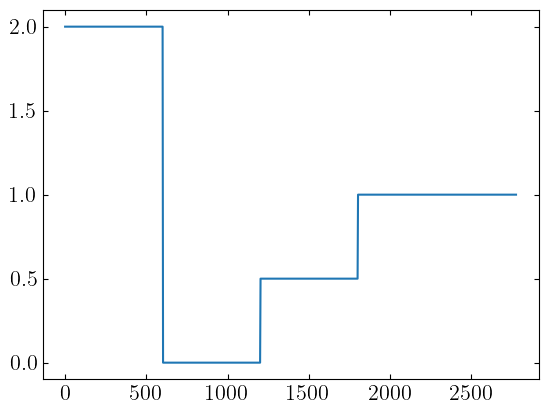

In [4]:

plt.plot(t, current(t))

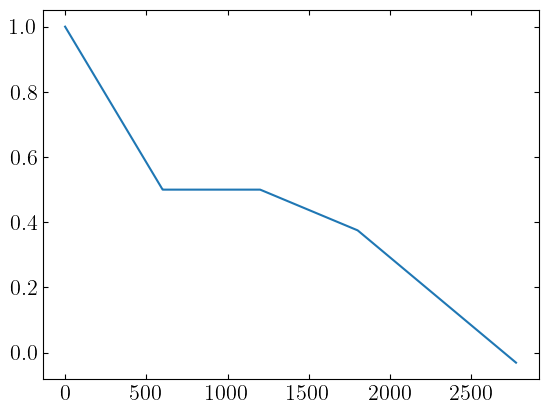

In [5]:
def soc_dot(z,t,Q=Q):
    return -current(t) / Q

soc_sol = scipy.integrate.odeint(soc_dot, 1, t)
plt.plot(t, soc_sol)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pybamm/solvers/base_solver.py:1008: SolverWarning: While solving Doyle-Fuller-Newman model extrapolation occurred for ["Interpolant 'interpolating_function' upper bound"]
  self.check_extrapolation(solution, model.events)


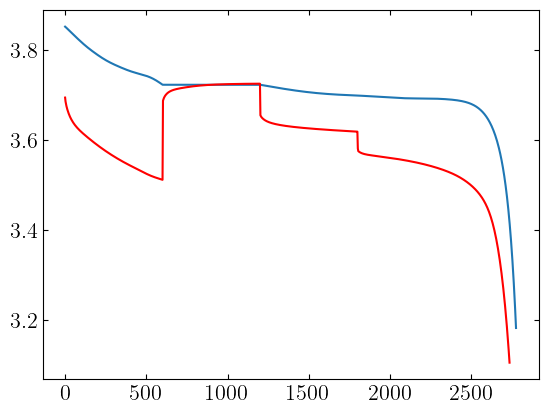

In [6]:
plt.plot(t,V_soc(soc_sol.flatten()))
tt,vv,ii = sim_PyBaMM.get_volt_variable(1)
plt.plot(tt,vv,'r')

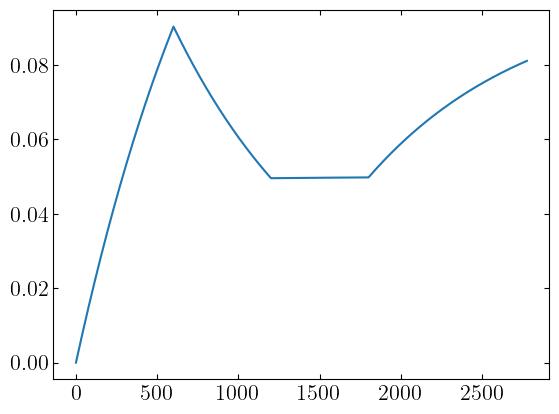

In [ ]:
def dU(u,t,i,R0,R1,C1):
    return -u/(R1*C1) +  current(t) /C1



y0 = 0
U_sol = scipy.integrate.odeint(dU, y0, t, args=(i0, R0, R1, C1))

plt.plot(t, U_sol)


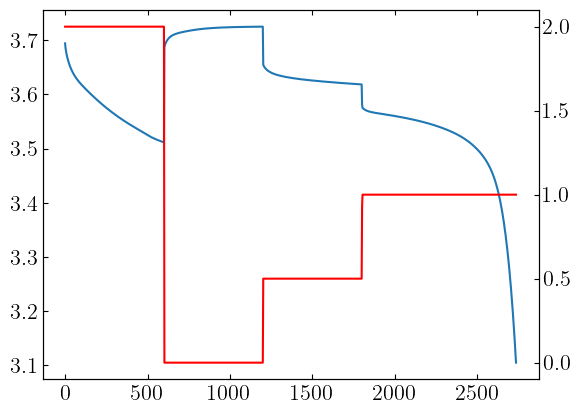

In [8]:
tt,vv,ii = sim_PyBaMM.get_volt_variable(1)

f, ax = plt.subplots()
axt = ax.twinx()
ax.plot(tt,vv)
axt.plot(tt,ii,'r')

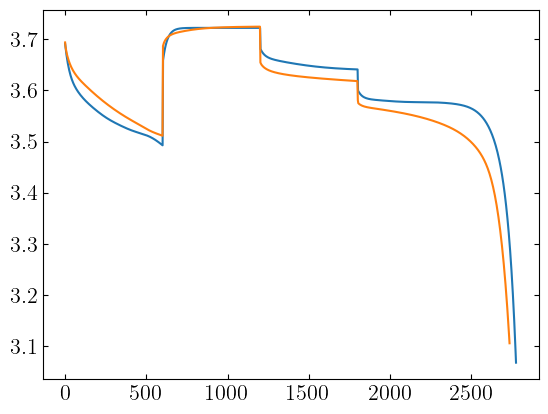

In [9]:


tt, vv, ii, = sim_PyBaMM.get_volt_variable(1)

R0 = 0.08
R1 = 0.035
C1 = 750

U_sol = scipy.integrate.odeint(dU, y0, t, args=(i0, R0, R1, C1))
soc_sol = scipy.integrate.odeint(soc_dot, 1, t)
V = V_soc(soc_sol.flatten()) - current(t) * R0 - U_sol.flatten()
plt.plot(t, V)
plt.plot(tt,vv)

Text(0, 0.5, 'Voltage [V]')

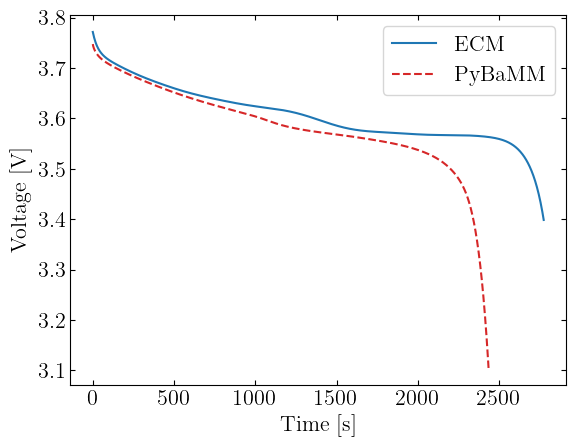

In [10]:
plt.plot(*simulate(R0, R1, C1,R2,C2), label = 'ECM')
plt.plot(*sim_PyBaMM.get_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')

<Figure size 640x480 with 0 Axes>

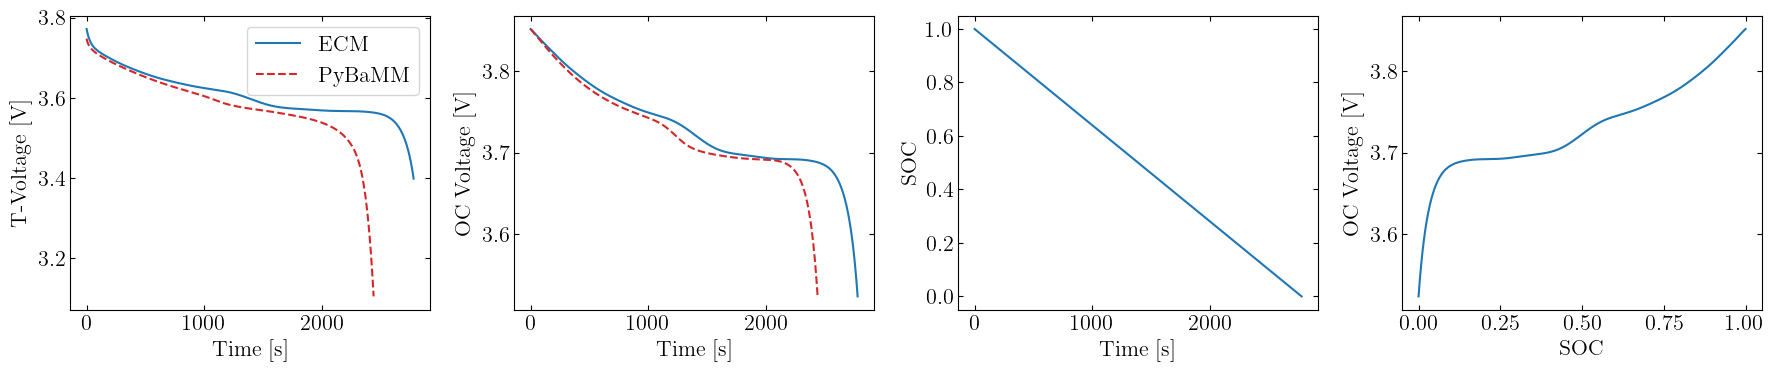

In [11]:
plt.figure()

fig, ax = plt.subplots(1,4, figsize = (18,4))

ax[0].plot(*simulate(R0, R1, C1,R2,C2), label = 'ECM')
ax[0].plot(*sim_PyBaMM.get_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[0].legend()
ax[1].plot(t,V_soc(SOC(i0)) )
ax[1].plot(*sim_PyBaMM.get_OC_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[2].plot(t, SOC(i0,))
ax[3].plot(SOC(i0),V_soc(SOC(i0)))
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('T-Voltage [V]')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('OC Voltage [V]')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('SOC')
ax[3].set_xlabel('SOC')
ax[3].set_ylabel('OC Voltage [V]')
plt.tight_layout()


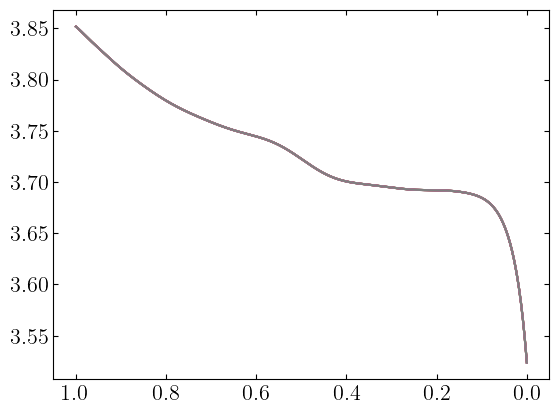

In [12]:
for i in np.arange(2,10):
    i /= 4
    plt.plot(SOC(i),V_soc(SOC(i)))
    # inverting x-axis to match the typical SOC-OCV curve orientation

plt.gca().invert_xaxis()
    #plt.plot(*sim_PyBaMM.get_OC_voltage(i), label = 'PyBaMM', linestyle = '--',color = 'tab:red')

[-18.55534574  63.3746161  -83.98589518  54.26142329 -17.38212651
   2.57970588   3.55535818]


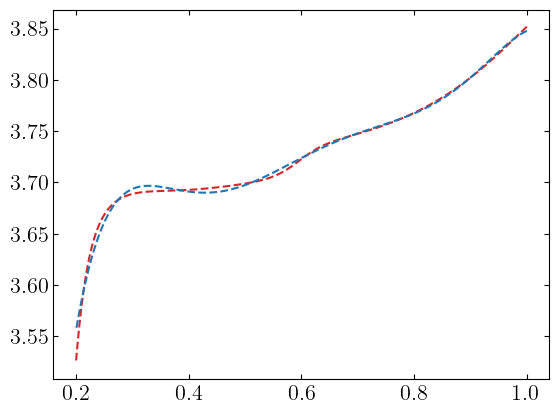

In [13]:
i0 = 1
t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0)
params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 6)
p = np.poly1d(params)
print(params)
plt.plot(np.linspace(1,0.2,len(t_oc)), V_oc, label = 'PyBaMM OC Voltage', linestyle = '--',color = 'tab:red')
plt.plot(np.linspace(1,0.2,len(t_oc)), p(np.linspace(1,0,len(t_oc))), label = 'Fitted OC Voltage', linestyle = '--',color = 'tab:blue')


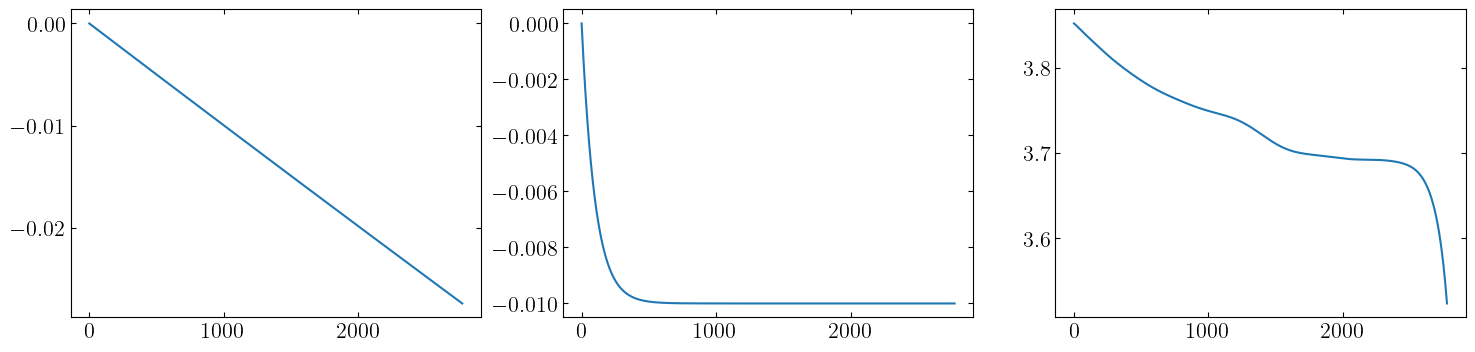

In [14]:
fig, ax = plt.subplots(1,3, figsize = (18,4))
R1 = 1
C1 = 100000
ax[0].plot(t,-i0 * (Z(R1, C1, t)), label = 'Z_1')
ax[1].plot(t,-i0 * (Z(R2, C2, t)), label = 'Z_2')
ax[2].plot(t,V_soc(SOC(i0)), label = 'Z_2')

0.2	2507.5168720644633 	 0.6965324644623521 	 1114
0.4	2487.9172978453194 	 0.6910881382903665 	 1139
0.6	2469.641472114819 	 0.6860115200318936 	 1105
0.8	2451.9757382887506 	 0.6811043717468748 	 1085
1.0	2434.608029196961 	 0.6762800081102677 	 1052
1.2	2417.369202865356 	 0.6714914452403744 	 1047
1.4	2400.153073222564 	 0.6667091870062684 	 1039
1.6	2382.881963036649 	 0.6619116563990695 	 1040
1.8	2365.5015743735157 	 0.6570837706593103 	 1041
2.0	2347.9639626649664 	 0.6522122118513793 	 1025
2.2	2330.22117369823 	 0.6472836593606196 	 1023
2.4	2312.1837052813294 	 0.642273251467036 	 997
2.6	2293.671707639988 	 0.6371310298999967 	 991
2.8	2274.3844789083223 	 0.631773466363422 	 973
3.0	2253.7600632686226 	 0.6260444620190639 	 981
3.2	2230.397704682985 	 0.6195549179674952 	 978
3.4	2198.9215466871397 	 0.6108115407464281 	 946
3.6	2145.149090882343 	 0.5958747474673175 	 935
3.8	2073.3343398814745 	 0.5759262055226311 	 907
4.0	1993.6119014045028 	 0.5537810837234743 	 866
4

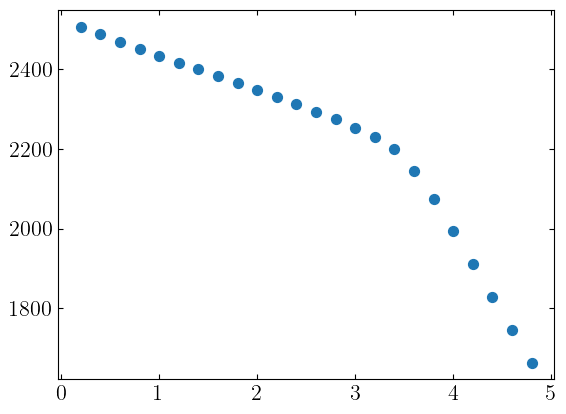

In [92]:
for i in np.arange(1,25):
    i /= 5
    t,U,t_e = sim_PyBaMM.get_discharge_capacity_II(i)
    plt.scatter(i,i * t[-1], label = f'i = {i} A', s = 50,c = 'tab:blue')
    print(f'{i}\t{i * t[-1]} \t {U[-1]} \t {len(t_e)}')


In [16]:
u_obs = sim_PyBaMM.get_voltage(i0)[1]

In [17]:
def model(theta):
    R1, R2,C1,C2 = theta
    U = simulate_I(R1, R2,C1,C2)[1]
    return U


def log_prior(theta):
    R1,R2,C1,C2 = theta

    R1_lims = (0.01, 1e4)
    R2_lims = (0.01, 1e4)
    C1_lims = (1, 100000)
    C2_lims = (1, 100000)
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_R2 = stats.uniform.logpdf(R2, loc=R2_lims[0], scale=R2_lims[1] - R2_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])
    p_C2 = stats.uniform.logpdf(C2, loc=C2_lims[0], scale=C2_lims[1] - C2_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1 + p_R2 + p_C2

def log_likelihood(theta,U_obs = u_obs):
    U_model = model(theta)
    sigma = 0.01  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior(theta):
    log_post = log_likelihood(theta) + log_prior(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post



In [ ]:
u_obs = vv
import time


In [ ]:
start = time.perf_counter() * 1000
UU= model_II([0.1,0.01,1000])
end = time.perf_counter() * 1000
print(f'Model evaluation time: {end - start:.4f} seconds')

In [ ]:
def model_II(theta):
    R0,R1,C1 = theta
    U_sol = scipy.integrate.odeint(dU, y0, t, args=(1, R0, R1, C1))
    soc_sol = scipy.integrate.odeint(soc_dot, 1, t)
    V = V_soc(soc_sol.flatten()) - current(t) * R0 - U_sol.flatten()
    return V 


def log_prior_II(theta):

    R0,R1,C1 = theta

    R0_lims = (0.001, 1)
    R1_lims = (0.001, 100)

    C1_lims = (1, 1e5)
    p_R0 = stats.uniform.logpdf(R0, loc=R0_lims[0], scale=R0_lims[1] - R0_lims[0])
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1  + p_R0

def log_likelihood_II(theta,U_obs = u_obs):
    U_model = model_II(theta)
    sigma = 1e-1  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior_II(theta):
    log_post = log_likelihood_II(theta) + log_prior_II(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post

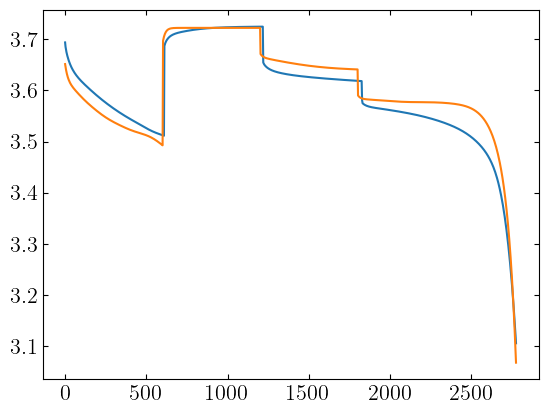

In [79]:
plt.plot(t,u_obs)
plt.plot(t,model_II([0.1, 0.015,1000]))

In [57]:
def samples_MCMC(post,nwalkers = 50, burninproc =10 , iterations = 10000):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 4  # Since theta has three parameters:

    rng = np.random.default_rng(seed = 1337)

    R_lims = (0.001, 1e4)
    C_lims = (1, 1e5)
    R1   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    R2   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    C1   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)
    C2   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)

    p0 = np.vstack((R1,R2,C1,C2)).T

    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [67]:
def samples_MCMC_II(post,nwalkers = 32, burninproc =10 , iterations = 5000):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 3  # Since theta has three parameters:

    #rng = np.random.default_rng(seed = 1337)

    R1_lims = (0.001, 1e1)
    R0_lims = (0.001, 1)
    C_lims = (1, 1e5)
    R0   = np.random.uniform(R0_lims[0],R0_lims[1],size = nwalkers)
    R1   = np.random.uniform(R1_lims[0],R1_lims[1],size = nwalkers)
    C1   = np.random.uniform(C_lims[0],C_lims[1],size = nwalkers)
    #C2   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)

    p0 = np.vstack((R0,R1,C1)).T

    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [68]:
#samples = samples_MCMC(log_posterior)
samples = samples_MCMC_II(log_posterior_II)

100%|██████████| 5000/5000 [07:32<00:00, 11.06it/s]


In [69]:
burned_samples = samples[:10 * len(samples) // 100] 
samples = samples[10 * len(samples) // 100:]

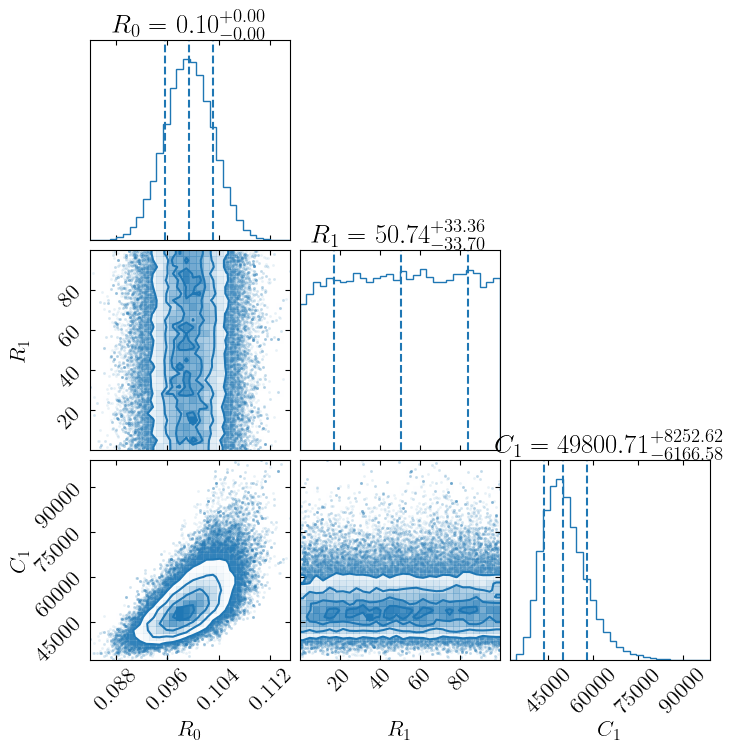

In [ ]:
# fig = corner.corner(samples, labels=[r"$R_1$", r"$R_2$",r"$C_1$",r"$C_2$"], color='tab:blue',
#                 show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
#                 plot_density=True,quantiles=[0.16,0.5,0.84])
fig = corner.corner(samples, labels=[r"$R_0$",r"$R_1$",r"$C_1$"], color='tab:blue',
                show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
                plot_density=True,quantiles=[0.16,0.5,0.84])

#plt.savefig(f'ECM_figs/ECM_corner.pdf')

In [76]:
def running_mean(x, factor=0.01):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))

    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))

    return average


def trace_plotter(samples):
    ndim = samples.shape[1]
    fig, axes = plt.subplots(ndim, figsize=(5, 6), sharex=True)
    labels = [r"$R_0$", r"$R_1$",r"$C_1$",r"$C_2$"]
    mean = running_mean(samples)
    if ndim == 1:
        axes.plot(samples, "tab:blue", alpha=0.7)
        axes.plot(np.arange(len(mean)), mean, color='tab:red')
        axes.tick_params(direction='in')
        axes.set_ylabel('$\\Omega_{M,0}$')
        axes.set_xlabel("step number");
    else:
        for i,ax in zip(range(ndim),axes):
            ax.plot(samples[:, i], "tab:blue", alpha=0.7)
            ax.plot(np.arange(len(mean)), mean[:,i], color='tab:red')
            ax.set_ylabel(labels[i])
            ax.tick_params(direction='in')

        axes[-1].set_xlabel("step number");
    plt.tight_layout()
    plt.savefig('ECM_figs/ECM_trace_plot.pdf')
    plt.show()

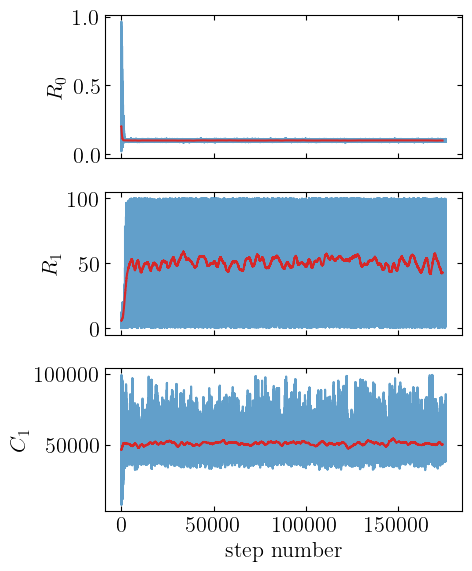

In [77]:
trace_plotter(np.vstack((burned_samples,samples)))
#plt.savefig('ECM_figs/ECM_trace_plot.pdf')

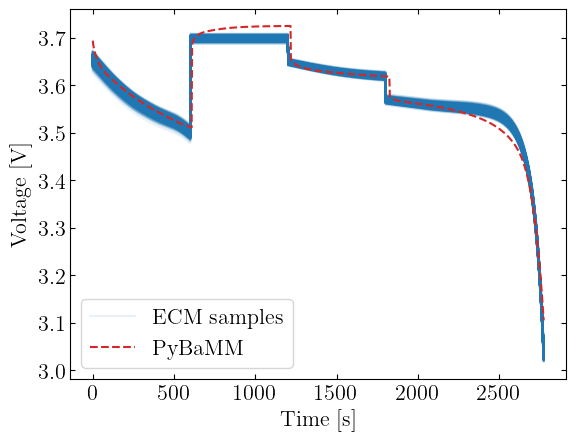

In [ ]:
Nsamp = 1000
sample_idx = random.sample(range(0, len(samples)), Nsamp)

t = simulate_II(*samples[0])[0]
U_true = sim_PyBaMM.get_voltage(i0)[1]
for i in sample_idx:
    plt.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1)
    #plt.plot(t,model(samples[i]), color='tab:blue', alpha=0.1)

#    plt.plot(*simulate_II(*samples[i]), color='tab:blue', alpha=0.1)
plt.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1, label = 'ECM samples')
plt.plot(t,u_obs, label = 'PyBaMM', linestyle = '--',color = 'tab:red')
#plt.plot(t,V_soc(SOC(i0)), label = 'SOC', linestyle = '--',color = 'tab:green')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
#plt.savefig('ECM_figs/ECM_MAP_preds.pdf')

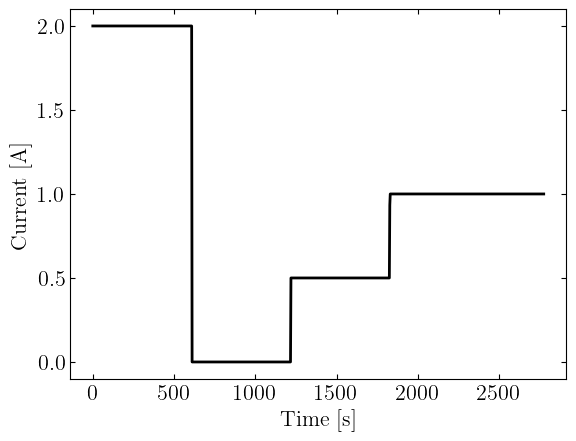

In [ ]:
plt.plot(t,ii, label = 'ECM', lw = 2, color = 'black')
plt.xlabel('Time [s]')
plt.ylabel('Current [A]')
#plt.savefig('ECM_figs/ECM_current.pdf')